# 水果分类决策树实验
## 水果分类用决策树的意义
- 规则清晰可解释，便于把模型决策转化为分拣与质检标准。
- 对特征尺度不敏感，适合多种传感器/图像统计特征的快速建模。
- 训练与推理速度快，利于生产线上实时分拣与边缘设备部署。

## 多分类问题
- 目标是将样本划分到 3 个及以上类别，本案例为 5 类水果分类（纯代码生成）。
- 常用指标：准确率、宏平均/加权平均的 Precision、Recall、F1。

## 决策树讲解
- 决策树通过不断选择“最能区分样本”的特征及阈值进行划分，形成从根到叶的判别路径。
- 节点划分依据通常是信息增益或基尼指数，目标是让子节点更“纯”。
- 叶节点给出类别预测；从根到叶的一条路径就是一条可解释的分类规则。
- 树越深越容易过拟合，可通过 `max_depth`、`min_samples_leaf` 等进行约束。

## 决策树分类器
- 通过一系列特征阈值判断形成树结构完成分类。
- 优点：可解释性强、对特征缩放不敏感。
- 关键超参：`max_depth` 限制树深度防止过拟合。

## 模型评估
- 使用 `classification_report` 与可视化决策树规则。
- 理解树的决策路径（如：高>8 → 苹果/芒果）。

下面开始按步骤完成实验流程，先准备运行环境。

# 1. 导入需要的库

本节代码将导入依赖并完成绘图与随机种子设置。

In [2]:
# 1. 导入需要的库
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings

# 隐藏所有警告信息
warnings.filterwarnings('ignore')

# 设置中文显示和负号显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子，确保结果可复现
np.random.seed(42)

环境准备就绪后，下一步生成模拟水果数据集。

# 2. 生成模拟水果数据集
定义 5 类水果的特征分布，通过正态分布随机生成 500 条样本。

下面代码会按设定分布生成样本，并保存为CSV以便复用。

In [3]:
# 2. 生成模拟水果数据集
# 定义 5 类水果的特征分布（均值和标准差）
# 特征：mass(质量), width(宽度), height(高度), color_score(颜色评分)
fruit_specs = {
    'apple': {'mean': [180, 7.0, 7.2, 0.8], 'std': [20, 0.3, 0.3, 0.05], 'n': 100},
    'banana': {'mean': [120, 3.0, 18.0, 0.6], 'std': [15, 0.2, 1.0, 0.05], 'n': 100},
    'orange': {'mean': [150, 7.5, 7.5, 0.4], 'std': [15, 0.4, 0.4, 0.05], 'n': 100},
    'lemon': {'mean': [80, 5.0, 6.0, 0.3], 'std': [10, 0.2, 0.3, 0.03], 'n': 100},
    'mango': {'mean': [200, 7.5, 8.5, 0.7], 'std': [25, 0.4, 0.5, 0.05], 'n': 100}
}

# 生成数据
data = []
for fruit, specs in fruit_specs.items():
    # 生成服从正态分布的特征数据
    features = np.random.normal(loc=specs['mean'], scale=specs['std'], size=(specs['n'], 4))
    # 确保数值为正
    features = np.abs(features)
    # 添加标签
    labels = np.full(specs['n'], fruit)
    # 组合
    for f, l in zip(features, labels):
        data.append([l, *f])

# 转换为 DataFrame
df = pd.DataFrame(data, columns=['fruit_name', 'mass', 'width', 'height', 'color_score'])
print(f"生成数据集大小：{df.shape}")
print(df.head(10))

# 保存数据集到 data 目录
import os
data_dir = os.path.join(os.getcwd(), "data")
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, "fruit_dataset.csv")
df.to_csv(data_path, index=False, encoding="utf-8-sig")
print(f"\n数据集已保存到：{data_path}")

# 描描统计
print("\n水果特征统计信息：")
print(df.groupby('fruit_name')[['mass', 'width', 'height', 'color_score']].mean().round(2))

生成数据集大小：(500, 5)
  fruit_name        mass     width    height  color_score
0      apple  189.934283  6.958521  7.394307     0.876151
1      apple  175.316933  6.929759  7.673764     0.838372
2      apple  170.610512  7.162768  7.060975     0.776714
3      apple  184.839245  6.426016  6.682525     0.771886
4      apple  159.743378  7.094274  6.927593     0.729385
5      apple  209.312975  6.932267  7.220258     0.728763
6      apple  169.112346  7.033277  6.854702     0.818785
7      apple  167.987226  6.912492  7.019488     0.892614
8      apple  179.730056  6.682687  7.446763     0.738958
9      apple  184.177272  6.412099  6.801544     0.809843

数据集已保存到：d:\xiangmu\4-shuiguo\data\fruit_dataset.csv

水果特征统计信息：
              mass  width  height  color_score
fruit_name                                    
apple       179.80   7.01    7.21         0.80
banana      118.23   2.99   18.00         0.60
lemon        80.14   5.02    6.01         0.30
mango       200.01   7.56    8.50         0.71

数据集生成完毕，接下来划分训练集和测试集。

# 3. 划分训练集和测试集

下面执行划分，并检查训练/测试规模与类别分布。

In [54]:
# 3. 划分训练集和测试集
# 特征(X)和标签(y)
X = df[['mass', 'width', 'height', 'color_score']]
y = df['fruit_name']

# 按 80-20 划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练集大小：{X_train.shape}")
print(f"测试集大小：{X_test.shape}")

# 统计训练集类別分布
print("\n训练集类別分布:")
print(y_train.value_counts().sort_index())

训练集大小：(400, 4)
测试集大小：(100, 4)

训练集类別分布:
fruit_name
apple     72
banana    86
lemon     76
mango     76
orange    90
Name: count, dtype: int64


完成数据划分后，进入模型训练阶段。

# 4. 训练决策树

决策树的训练预处理：
- `max_depth=3`: 限制树深度最多为 3 层，不仅保证可释性，也能截截过拟合
- `random_state=42`: 保证结果可重现
- 模型会自动了解每个特征的重要性（特征重要性）

下面训练决策树并打印训练完成提示。

In [55]:
# 4. 训练决策树
# max_depth=3 限制树深度，防止过拟合，同时保证可解释性
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
print("模型训练完成！")

模型训练完成！


模型训练完成后，进行预测并评估性能。

# 5. 模型预测与准确率评估

下面输出准确率与分类报告，便于整体对比。

In [56]:
# 5. 模型预测与准确率评估
y_pred = clf.predict(X_test)

print("="*50)
print("决策树多分类一体化流程模拟")
print("="*50)
print(f"\n模型准确率: {accuracy_score(y_test, y_pred):.3f}")

print("\n[详细分类报告]")
print("指标定义:")
print("  - Precision：预测为该类的样本中，有多少是真正该类。")
print("  - Recall：真正该类的样本中，什么模型预测出来。")
print("  - F1-score：Precision和Recall的调和平均数。\n")
print(classification_report(y_test, y_pred))

决策树多分类一体化流程模拟

模型准确率: 0.990

[详细分类报告]
指标定义:
  - Precision：预测为该类的样本中，有多少是真正该类。
  - Recall：真正该类的样本中，什么模型预测出来。
  - F1-score：Precision和Recall的调和平均数。

              precision    recall  f1-score   support

       apple       0.97      1.00      0.98        28
      banana       1.00      1.00      1.00        14
       lemon       1.00      1.00      1.00        24
       mango       1.00      0.96      0.98        24
      orange       1.00      1.00      1.00        10

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



评估完成后，继续可视化决策树结构。

# 6. 决策树结构可视化

下面绘制树形结构，直观看到分裂规则。

下图每个节点投票较多的策略为最终预测。



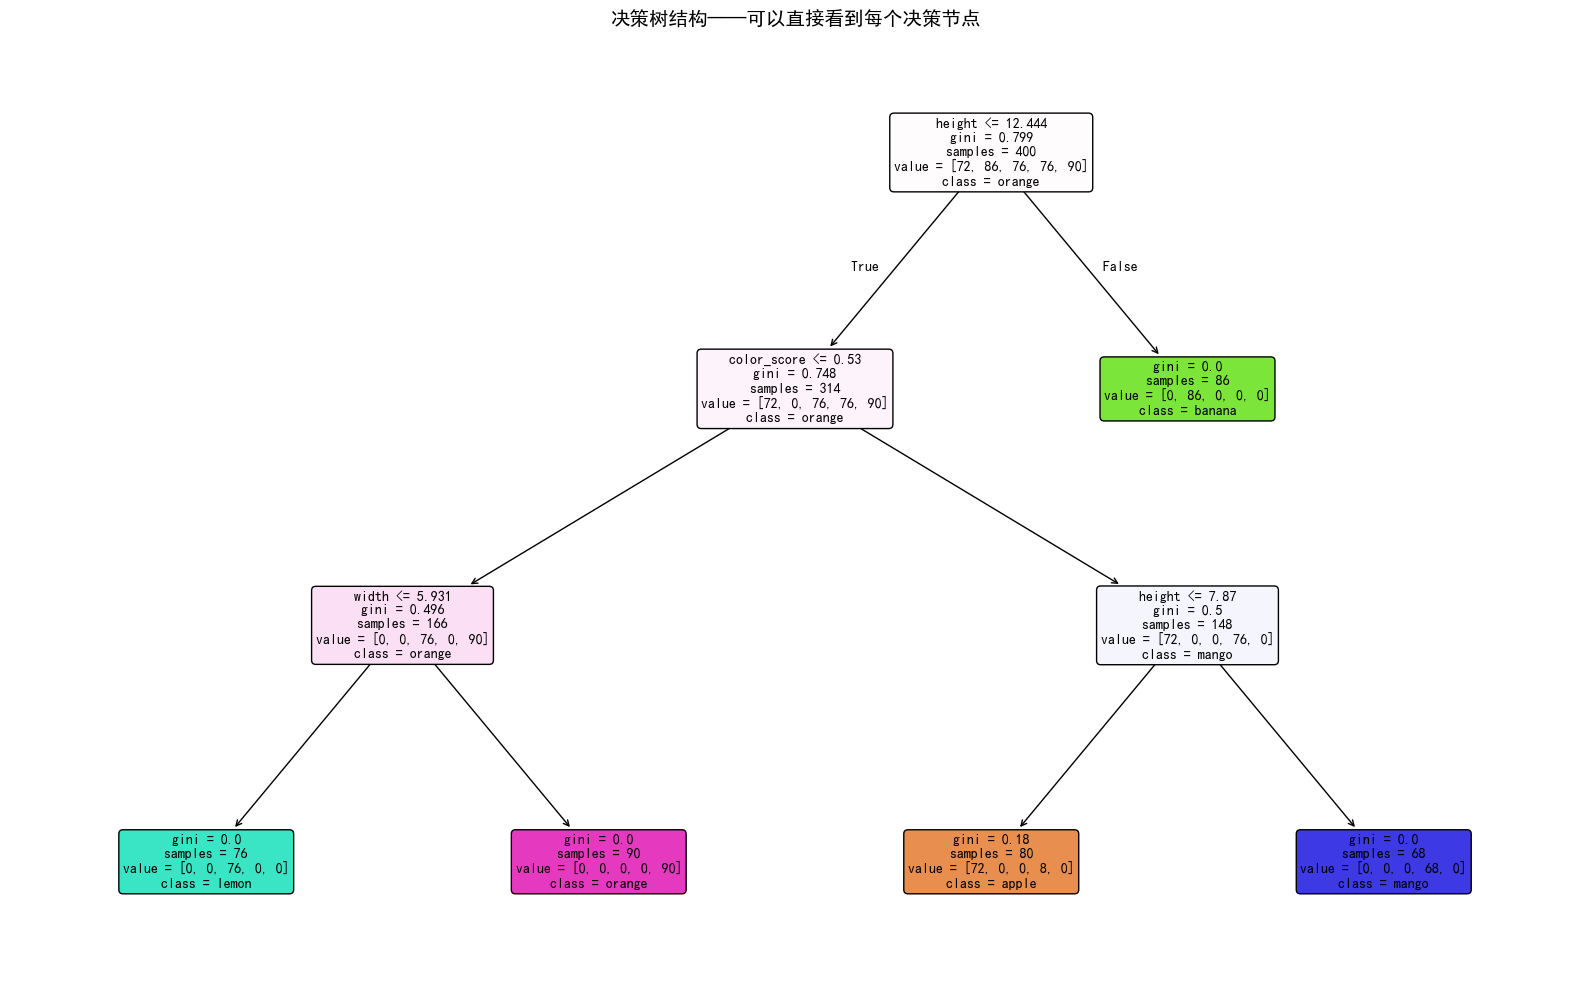

In [57]:
# 6. 决策树结构可视化
print("下图每个节点投票较多的策略为最终预测。\n")
plt.figure(figsize=(16, 10))
plot_tree(clf, feature_names=X.columns, class_names=sorted(fruit_specs.keys()),
          filled=True, rounded=True, fontsize=10)
plt.title("决策树结构——可以直接看到每个决策节点", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

接下来观察二维特征分布，看看类间差异。

# 7. 数据分布可视化（宽度 vs 高度）

下面绘制宽度-高度散点图，并按类别着色。

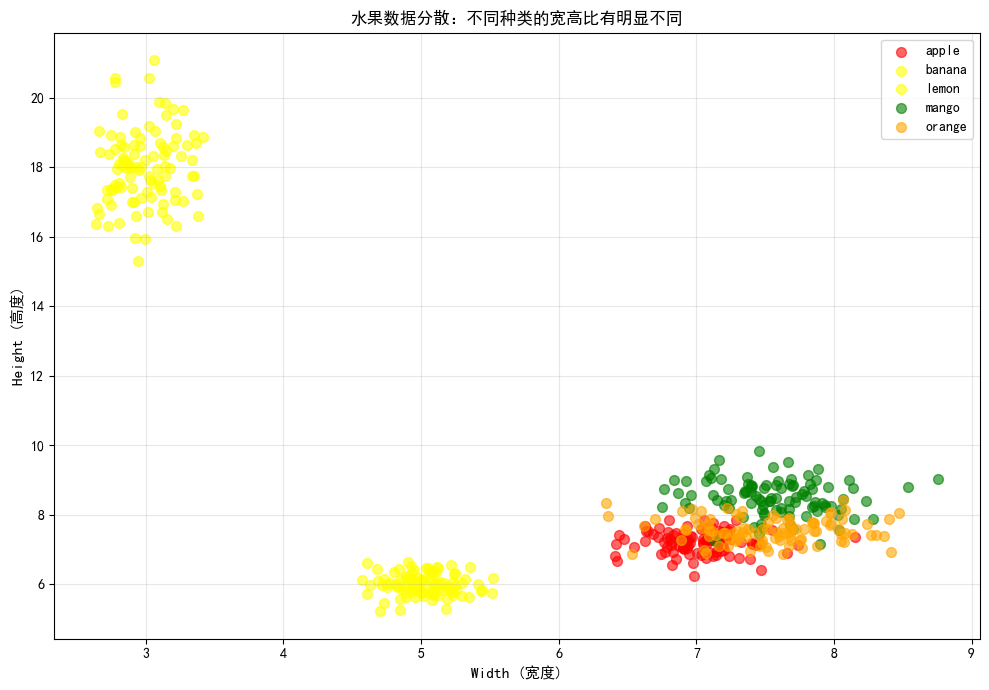

In [58]:
# 7. 数据分布可视化（width vs height）
import matplotlib.patches as mpatches
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
colors = {'apple': 'red', 'banana': 'yellow', 'orange': 'orange', 'lemon': '#FFFF00', 'mango': 'green'}
for fruit in sorted(fruit_specs.keys()):
    mask = df['fruit_name'] == fruit
    ax.scatter(df[mask]['width'], df[mask]['height'], label=fruit, alpha=0.6, s=50, color=colors[fruit])
ax.set_xlabel('Width (宽度)', fontsize=11)
ax.set_ylabel('Height (高度)', fontsize=11)
ax.set_title('水果数据分散：不同种类的宽高比有明显不同', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

接下来用混淆矩阵进一步评估分类效果。

# 8. 混淆矩阵可视化

下面绘制混淆矩阵，查看各类别的误判情况。

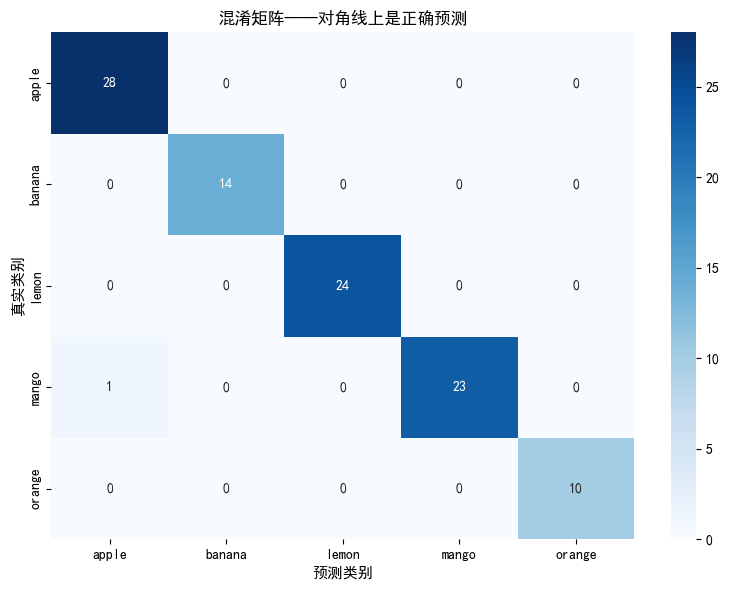

In [59]:
# 8. 混淆矩阵可视化
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=sorted(fruit_specs.keys()))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(fruit_specs.keys()),
            yticklabels=sorted(fruit_specs.keys()))
plt.xlabel('预测类别', fontsize=11)
plt.ylabel('真实类别', fontsize=11)
plt.title('混淆矩阵——对角线上是正确预测', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

接下来分析特征重要性，了解模型依赖的关键特征。

# 9. 特征重要性分析
哪些特征对决策树的决策最有影响力？

下面输出特征重要性并绘制条形图。

[特征重要性排名]
  mass: 0.0000 (*)
  width: 0.2702 (***)
  height: 0.4723 (***)
  color_score: 0.2575 (***)


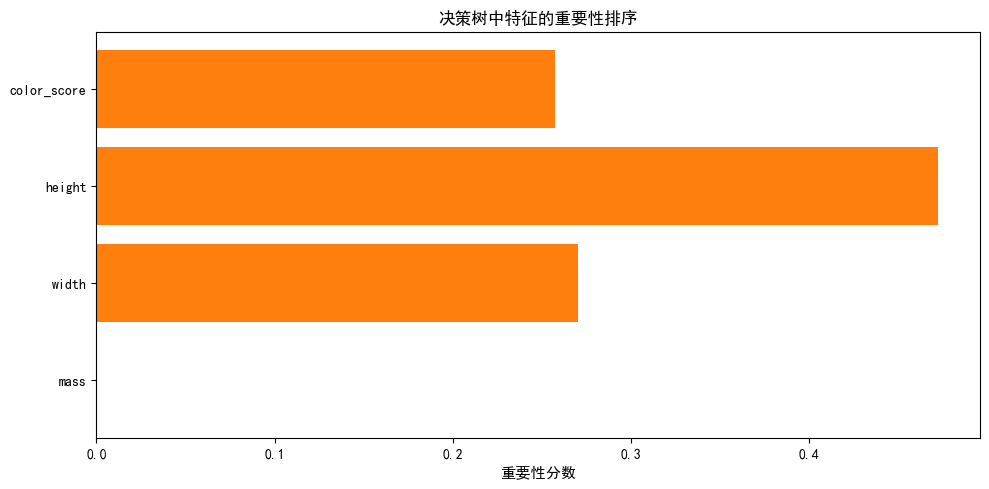


解读：最上面的特征对决策树的分类决策最重要。


In [ ]:
# 9. 特征重要性分析
feature_importance = clf.feature_importances_

print("[特征重要性排名]")
for feature, importance in zip(X.columns, feature_importance):
    print(f"  {feature}: {importance:.4f} ({'***' if importance > 0.2 else '**' if importance > 0.1 else '*'})")

# 可视化特征重要性
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#ff7f0e' if imp > 0.2 else '#2ca02c' if imp > 0.1 else '#1f77b4' for imp in feature_importance]
ax.barh(X.columns, feature_importance, color=colors_bar)
ax.set_xlabel('重要性分数', fontsize=11)
ax.set_title('决策树中特征的重要性排序', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n解读：最上面的特征对决策树的分类决策最重要。")

基于重要性结果，下面给出规则性的总结说明。

# 10. 关键水果识别规则总结

根据决策树的结构，不同水果的典型特征：

| 水果 | 质量 | 宽/高 | 颜色 | 特征器 |
|------|--------|--------|--------|----------|
| 苹果 | 180 | 7.0/7.2 | 0.8 | 中等质量，圆形 |
| 香蕉 | 120 | 3.0/18.0 | 0.6 | 轻，低宽/高 |
| 橙子 | 150 | 7.5/7.5 | 0.4 | 中质量，正方形 |
| 柠檬 | 80 | 5.0/6.0 | 0.3 | 轻，低颜色评分 |
| 芒果 | 200 | 7.5/8.5 | 0.7 | 重，中高颜色 |

例：按照决策树'height > 8.5' 判断为芒果，按'width < 3.5' 决策为香蕉

最后补充拓展与思考题，便于深入理解与延伸。

# 11. 拓展与思考（含解答思路）

1. 如果把颜色评分噪声放大，哪些水果最容易被混淆？
- 思路：对 `color_score` 加入更大方差，重新训练并查看混淆矩阵；对比原混淆矩阵，找出误判最多的类别对。

2. 决策树深度对模型有什么影响？如何选 `max_depth`？
- 思路：遍历不同 `max_depth`，记录训练/测试准确率与学习曲线；观察过拟合/欠拟合拐点，用交叉验证或验证集选择最优深度。

3. 若只保留 2 个特征（如 width、height），模型性能会怎样变化？
- 思路：在特征子集上重复训练与评估，比较准确率、宏平均 F1 和 ROC；讨论特征维度减少对可分性的影响。

4. 如何提高模型的可解释性与稳定性？
- 思路：导出树结构、可视化决策路径；限制树深度与叶节点样本数；使用 `random_state` 固定划分以保证复现。

5. 模拟数据与真实数据差异如何处理？
- 思路：收集真实样本，做分布对比（均值/方差/相关性）；必要时进行特征标准化与重采样；考虑更丰富特征或更稳健模型。

6. 若类别不平衡（某类水果样本很少）应如何改进？
- 思路：使用 `class_weight='balanced'`，或过采样/欠采样；评价指标改用宏平均 F1 或 PR 曲线。